In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.cluster import KMeans
from scipy.spatial import distance
%matplotlib widget

In [2]:
def slerp(p0, p1, t):
    omega = np.arccos(np.dot(p0 / np.linalg.norm(p0), p1 / np.linalg.norm(p1)))
    so = np.sin(omega)
    return 1 * (np.sin((1.0 - t) * omega) / so * p0 + np.sin(t * omega) / so * p1)


def interpolate_centers_slerp(centers, center_order, n_points=1000):
    interpolated = []
    for i in range(len(center_order)-1):
        start = centers[center_order[i]]
        end = centers[center_order[(i + 1)]]
        for t in np.linspace(0, 1, n_points):
            interpolated.append(slerp(start, end, t))
    return np.array(interpolated)

def interpolate_centers_slerp_point(center1, center2, n_points=10000):
    interpolated = []
    start = center1
    end = center2
    for t in np.linspace(0, 1, n_points):
        interpolated.append(slerp(start, end, t))
    return np.array(interpolated)


def spherical_expansion(data_point, num_points=5, radius=1.0):

    # Normalize the original data point
    norm_data_point = data_point / np.linalg.norm(data_point)

    expanded_points = []
    
    # Generate num_points random points along the sphere
    for _ in range(num_points):
        # Generate a random unit vector by normalizing a random vector from normal distribution
        random_unit_vector = np.random.randn(len(data_point))
        random_unit_vector /= np.linalg.norm(random_unit_vector)  # Normalize it
        
        # Perturb the original data point by the random direction scaled by the radius
        new_point = data_point + radius * random_unit_vector
        expanded_points.append(new_point)
    
    return np.array(expanded_points)

In [3]:
device = 'cuda'

out_path = "./out/"
out_path_params = out_path + "Driver_XYZ_params/"
params_file_name = 'Driver_XYZ_Params'
# top_path = "../traj/cyclicpeptide/N4IR/N4IR.prmtop"
# path = "../traj/cyclicpeptide/N4IR/N4IR_min_rmrp.dcd"
pdb_name = "Driver_Cyclic_Peptide_Prediction"

# par_id = 8000

# Load the latent space representation
all_z = np.load(out_path + 'visual/' + 'Driver_Cyclic_Peptide_Predictionlatent.npy')

In [4]:
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(all_z)

# Find points closest to cluster centers
centers = []
index = []

for center in kmeans.cluster_centers_:
    distances = distance.cdist([center], all_z)
    closest_index = np.argmin(distances)
    centers.append(all_z[closest_index])
    index.append(closest_index)

In [5]:
# Get the indices sorted by the values in the list
sorted_indices = sorted(range(len(index)), key=lambda i: index[i])
sorted_indices

[7, 4, 5, 8, 6, 0, 3, 1, 2, 9]

In [6]:
index

[8633, 12140, 14558, 11040, 2250, 6505, 7931, 1926, 7056, 15717]

In [7]:
centers = np.array(centers)
# center_order = [4, 3, 6, 2, 0, 7, 9, 1, 5, 8]
# center_order = sorted_indices
# # center_order = [5,9]

# # Perform SLERP interpolation
# interpolated_points = interpolate_centers_slerp(centers, center_order)

center1 = all_z[3661]
center2 = all_z[341]
interpolated_points = interpolate_centers_slerp_point(center1, center2)
interpolated_points

array([[ 15.405941, -17.790995, -32.40693 ],
       [ 15.411761, -17.798702, -32.39463 ],
       [ 15.417582, -17.806412, -32.382336],
       ...,
       [ 13.766359, -19.68881 ,  65.26309 ],
       [ 13.760349, -19.68132 ,  65.262054],
       [ 13.754338, -19.673828,  65.261024]], dtype=float32)

In [8]:
data_point = centers[0]
expanded_points = spherical_expansion(data_point, num_points=1000, radius=80)

# Output the original and new points
# print("Original Point:", data_point)
# print("Expanded Points:")
# print(expanded_points)

In [9]:
centers,closest_index

(array([[ 15.476902 , -18.006645 , -33.08524  ],
        [ -8.018833 , -41.90823  ,  42.229984 ],
        [-11.609748 , -45.674847 ,  27.452774 ],
        [ -4.3998103, -57.97168  ,  63.902706 ],
        [ 23.040035 , -18.284506 ,  55.883266 ],
        [ 25.509317 , -15.584251 , -24.843918 ],
        [ 13.542978 , -37.605473 ,  22.838118 ],
        [-12.871487 , -57.562202 ,  39.028614 ],
        [ -5.0761824, -41.33558  ,   3.1422098],
        [-14.840855 , -51.274727 ,  56.064518 ]], dtype=float32),
 15717)

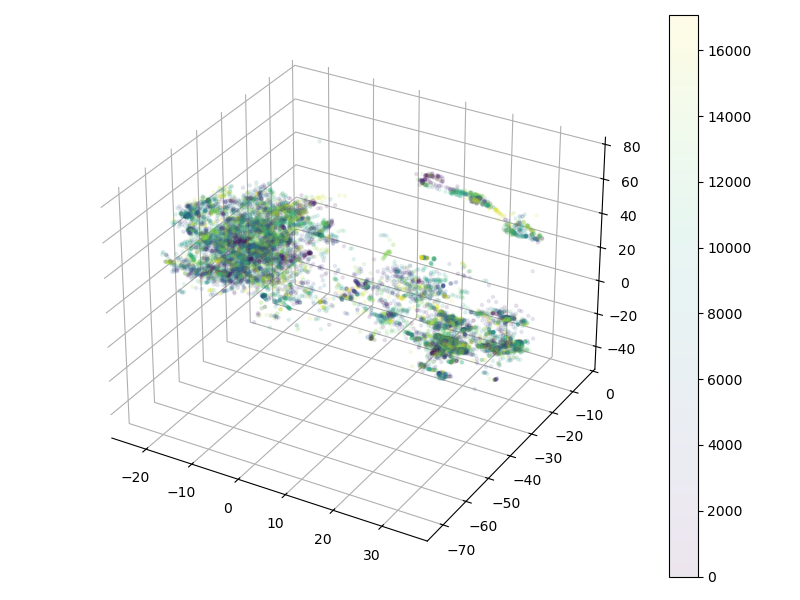

In [13]:
cmapT='viridis'
cmapV='winter'

fig = plt.figure(figsize = [8, 6])
ax = plt.axes(projection='3d')
p1 = ax.scatter3D(all_z[:,0], all_z[:,1], all_z[:,2], c=range(int(len(all_z))), alpha=0.1, cmap=cmapT, s=5)
# p2 = ax.scatter3D(interpolated_points[:,0], interpolated_points[:,1], interpolated_points[:,2], alpha=0.99, color='red')
# p3 = ax.scatter3D(interpolated_points1[:,0], interpolated_points1[:,1], interpolated_points1[:,2], alpha=0.99, color='blue')
# p3 = ax.scatter3D(centers[:,0], centers[:,1], centers[:,2], alpha=0.99, color='red')
# p3 = ax.scatter3D(expanded_points[:,0], expanded_points[:,1], expanded_points[:,2], alpha=0.99, color='red',s=1)



fig.colorbar(p1, ax=ax)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.xaxis.pane.set_edgecolor('w')
ax.yaxis.pane.set_edgecolor('w')
ax.zaxis.pane.set_edgecolor('w')

# ax.set_xlabel('Z1'); ax.set_ylabel('Z2'); ax.set_zlabel('Z3')
fig.tight_layout()
#plt.savefig('3D_latent_9000-9100.png')
plt.show()

In [14]:
# def slerp_rotate_manual(p0, p1, t, rotation_angle):
    
#     omega = np.arccos(np.dot(p0 / np.linalg.norm(p0), p1 / np.linalg.norm(p1)))
#     so = np.sin(omega)
#     interpolated = 1 * (np.sin((1.0 - t) * omega) / so * p0 + np.sin(t * omega) / so * p1)
    
    
#     # Linear axis (rotation axis) between start and end
#     axis = p0 - p1
#     axis = axis / np.linalg.norm(axis)  # Normalize axis

#     # Rodrigues' rotation formula
#     cos_theta = np.cos(rotation_angle)
#     sin_theta = np.sin(rotation_angle)
#     dot_product = np.dot(axis, interpolated)
#     cross_product = np.cross(axis, interpolated)

#     rotated_point = (
#         interpolated * cos_theta +
#         cross_product * sin_theta +
#         axis * dot_product * (1 - cos_theta)
#     )
    
#     return rotated_point

# def interpolate_slerp_with_rotation_manual(centers, center_order, rotation_angle, n_points=10000):

#     interpolated = []
#     # for i in range(len(center_order)):
#     #     start = centers[center_order[i]]
#     #     end = centers[center_order[(i + 1) % len(center_order)]]
#     #     for t in np.linspace(0, 1, n_points):
#     #         interpolated.append(slerp_rotate_manual(start, end, t, rotation_angle))
    
#     start = centers[center_order[0]]
#     end = centers[center_order[1]]
#     for t in np.linspace(0, 1, n_points):
#         interpolated.append(slerp_rotate_manual(start, end, t, rotation_angle))   
    
#     interpolated = np.array(interpolated) 
#     displacement = interpolated[0]-start
#     interpolated = interpolated - displacement

    
#     return interpolated


In [13]:
def slerp_rotate_manual(p0, p1, t, rotation_angle):
    
    omega = np.arccos(np.dot(p0 / np.linalg.norm(p0), p1 / np.linalg.norm(p1)))
    so = np.sin(omega)
    interpolated = 1 * (np.sin((1.0 - t) * omega) / so * p0 + np.sin(t * omega) / so * p1)
    
    
    # Linear axis (rotation axis) between start and end
    axis = p0 - p1
    axis = axis / np.linalg.norm(axis)  # Normalize axis

    # Rodrigues' rotation formula
    cos_theta = np.cos(rotation_angle)
    sin_theta = np.sin(rotation_angle)
    dot_product = np.dot(axis, interpolated)
    cross_product = np.cross(axis, interpolated)

    rotated_point = (
        interpolated * cos_theta +
        cross_product * sin_theta +
        axis * dot_product * (1 - cos_theta)
    )
    
    return rotated_point

def interpolate_slerp_with_rotation_manual(center1, center2, rotation_angle, n_points=1000):

    interpolated = []
    # for i in range(len(center_order)):
    #     start = centers[center_order[i]]
    #     end = centers[center_order[(i + 1) % len(center_order)]]
    #     for t in np.linspace(0, 1, n_points):
    #         interpolated.append(slerp_rotate_manual(start, end, t, rotation_angle))
    
    # start = centers[center_order[0]]
    # end = centers[center_order[1]]
    start = center1
    end = center2

    for t in np.linspace(0, 1, n_points):
        interpolated.append(slerp_rotate_manual(start, end, t, rotation_angle))   
    
    interpolated = np.array(interpolated) 
    
    t = np.linspace(0, 1, 1000)  # Parameter from 0 to 1
    A = 0.5  # Scaling factor (adjust to control magnitude)
    scaling_function = 1 + A * np.sin(np.pi * t) ** 2  # Ensures start and end remain unchanged
    
    interpolated = interpolated*scaling_function[:, np.newaxis]
    
    
    displacement = interpolated[0]-start
    interpolated = interpolated - displacement

    
    return interpolated


def interpolate_centers_slerp_point(center1, center2, n_points=10000):
    interpolated = []
    start = center1
    end = center2
    for t in np.linspace(0, 1, n_points):
        interpolated.append(slerp(start, end, t))
    return np.array(interpolated)


In [25]:
center1 = all_z[3661]
center2 = all_z[341]
interpolated_points_rotation = interpolate_slerp_with_rotation_manual(center1, center2, np.pi)

In [16]:
t = np.linspace(0, 1, 1000)  # Parameter from 0 to 1
A = 0.5  # Scaling factor (adjust to control magnitude)
scaling_function = 1 + A * np.sin(np.pi * t) ** 2  # Ensures start and end remain unchanged

In [18]:
multi_path = []
for i in range(12):
    interpolated_points_rotation = interpolate_slerp_with_rotation_manual(center1, center2, np.pi*i/6)
    # temp = interpolated_points_rotation * scaling_function[:, np.newaxis]
    multi_path.append(interpolated_points_rotation)

multi_path = np.array(multi_path).reshape(12000,3)

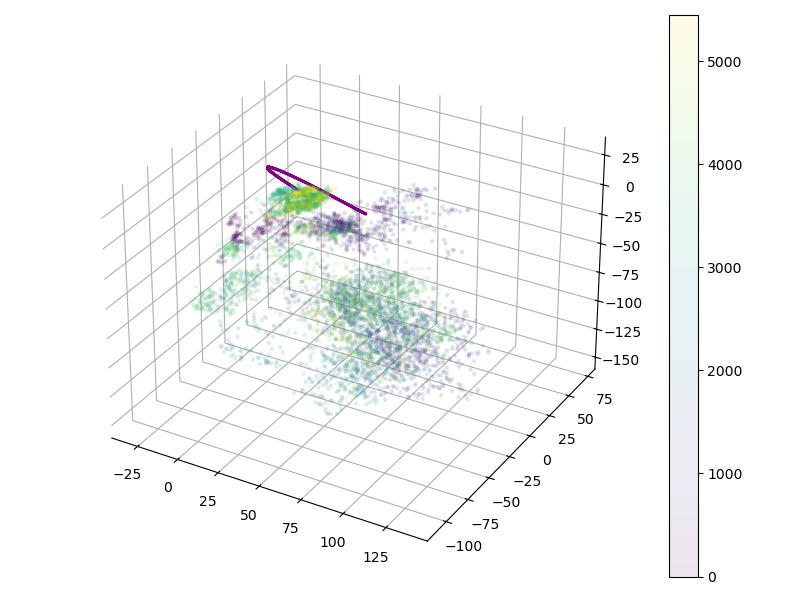

In [26]:
cmapT='viridis'
cmapV='winter'

fig = plt.figure(figsize = [8, 6])
ax = plt.axes(projection='3d')


p1 = ax.scatter3D(all_z[:,0], all_z[:,1], all_z[:,2], c=range(int(len(all_z))), alpha=0.1, cmap=cmapT, s=5)
# p2 = ax.scatter3D(multi_path[:,0], multi_path[:,1], multi_path[:,2], alpha=0.99, color='blue',s=1)
# p3 = ax.scatter3D(interpolated_points[:,0], interpolated_points[:,1], interpolated_points[:,2], alpha=0.99, color='red')
p4 = ax.scatter3D(interpolated_points_rotation[:,0], interpolated_points_rotation[:,1], interpolated_points_rotation[:,2], alpha=0.99, color='purple',s=1)
# p5 = ax.scatter3D(temp[:,0], temp[:,1], temp[:,2], alpha=0.99, color='orange',s=1)
# p3 = ax.scatter3D(expanded_points[:,0], expanded_points[:,1], expanded_points[:,2], alpha=0.99, color='red',s=1)

fig.colorbar(p1, ax=ax)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.xaxis.pane.set_edgecolor('w')
ax.yaxis.pane.set_edgecolor('w')
ax.zaxis.pane.set_edgecolor('w')

# ax.set_xlabel('Z1'); ax.set_ylabel('Z2'); ax.set_zlabel('Z3')
fig.tight_layout()
#plt.savefig('3D_latent_9000-9100.png')
plt.show()

In [15]:
np.save(out_path + 'visual/interpolated_latent_points_slerp.npy', interpolated_points)
# np.save(out_path + 'visual/interpolated_latent_points_slerp_rot_pi.npy', interpolated_points_rotation)
# np.save(out_path + 'visual/interpolated_latent_points_slerp.npy', expanded_points)